# Dim Reduction e Clustering su Lesioni

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering

# Per poter importare src se siamo dentro notebooks/
if str(Path.cwd().parent) not in sys.path:
    sys.path.append(str(Path.cwd().parent))

from src.analysis.distances import binary_pairwise_distance

%matplotlib inline

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Caricamento Matrice
matrix_path = Path('../data/derived/lesion_matrix/21-07_s1.1/matrix.npy')
X = np.load(matrix_path)
print(f"Shape della matrice: {X.shape}")

Shape della matrice: (1150, 254865)


In [7]:
# Calcolo Distanze (necessario per jaccard, dice)
# Gestisce anche euclidea passando la matrice npy direttamente.
metric = "euclidean" # Scegli tra: "euclidean", "jaccard", "dice"

if metric in ["jaccard", "dice"]:
    print(f"Precalcolo matrice di distanza per metrica: {metric}")
    X_dist = binary_pairwise_distance(X, metric)
else:
    X_dist = X
    print("Nessun precalcolo della distanza richiesto")

Nessun precalcolo della distanza richiesto


Fit UMAP...


/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


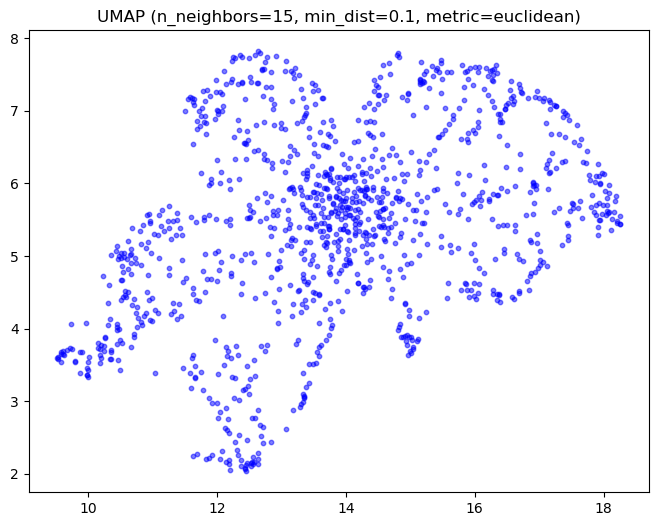

In [8]:
# --- UMAP ---
n_neighbors =50
n_components = 2
min_dist = 0.1
random_state = 42

reducer_umap = umap.UMAP(
    n_neighbors=n_neighbors,
    n_components=n_components,
    metric="precomputed" if metric in ["jaccard", "dice"] else metric,
    n_epochs=1000,
    learning_rate=1.0,
    init='spectral',
    min_dist=min_dist,
    spread=1.0,
    low_memory=False,
    set_op_mix_ratio=1.0,
    local_connectivity=1,
    repulsion_strength=1.0,
    negative_sample_rate=5,
    transform_queue_size=4.0,
    random_state=random_state
)

print("Fit UMAP...")
embedding_umap = reducer_umap.fit_transform(X_dist)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_umap[:, 0], embedding_umap[:, 1], s=10, alpha=0.5, c='blue')
plt.title(f'UMAP (n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric})')
plt.show()

Fit t-SNE...


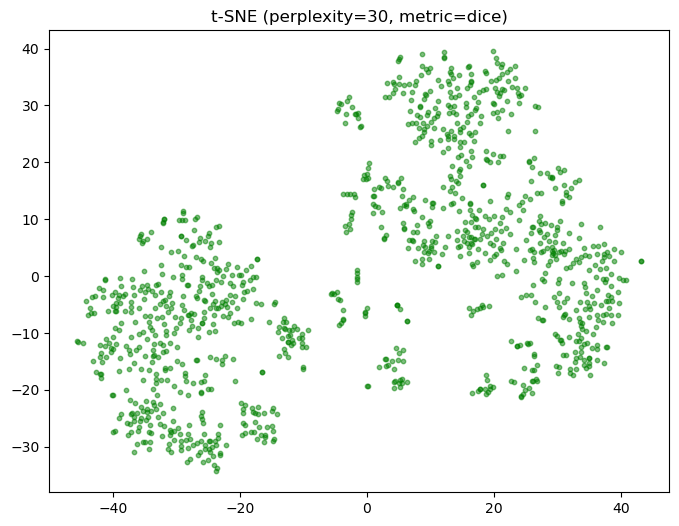

In [6]:
# --- t-SNE ---
perplexity = 30
random_state = 42

reducer_tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    metric="precomputed" if metric in ["jaccard", "dice"] else metric,
    init='pca' if metric not in ["jaccard", "dice"] else 'random',
    learning_rate='auto',
    random_state=random_state
)

print("Fit t-SNE...")
embedding_tsne = reducer_tsne.fit_transform(X_dist)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], s=10, alpha=0.5, c='green')
plt.title(f't-SNE (perplexity={perplexity}, metric={metric})')
plt.show()

Scegli quale embedding usare per i clustering successivi:

In [7]:
# DE-COMMENTA quello che vuoi usare (UMAP o t-SNE)
embedding_da_usare = embedding_umap
# embedding_da_usare = embedding_tsne

print(f"Embedding selezionato con shape: {embedding_da_usare.shape}")

Embedding selezionato con shape: (1150, 2)


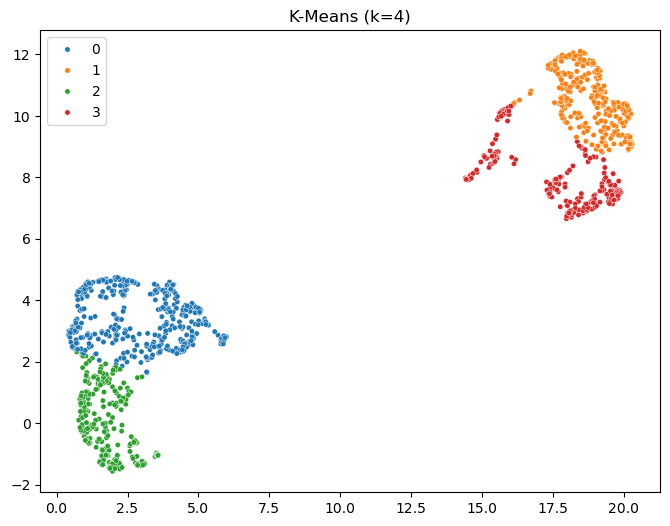

In [8]:
# --- KMeans ---
k_kmeans = 4
kmeans = KMeans(n_clusters=k_kmeans, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(embedding_da_usare)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=embedding_da_usare[:, 0], y=embedding_da_usare[:, 1], hue=labels_kmeans, palette='tab10', legend='full', s=15)
plt.title(f'K-Means (k={k_kmeans})')
plt.show()

/opt/anaconda3/envs/nemesis/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


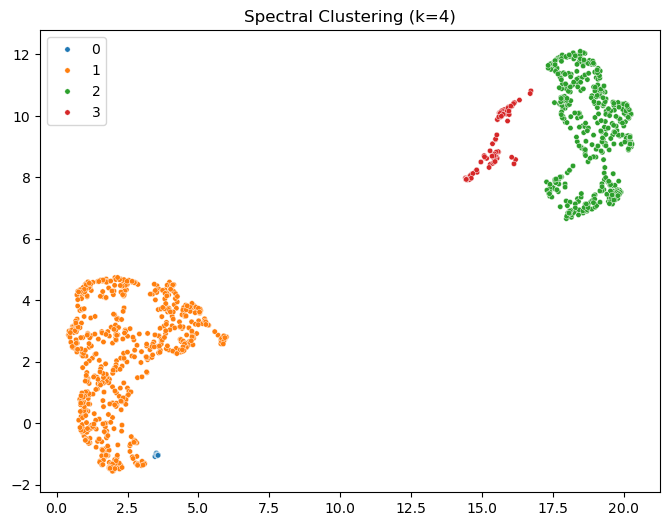

In [9]:
# --- Spectral Clustering ---
k_spectral = 4
spectral = SpectralClustering(n_clusters=k_spectral, affinity='nearest_neighbors', random_state=42)
labels_spectral = spectral.fit_predict(embedding_da_usare)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=embedding_da_usare[:, 0], y=embedding_da_usare[:, 1], hue=labels_spectral, palette='tab10', legend='full', s=15)
plt.title(f'Spectral Clustering (k={k_spectral})')
plt.show()

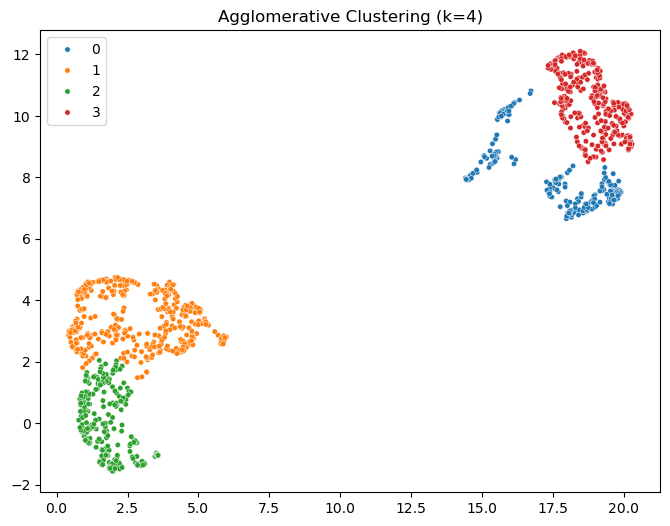

In [10]:
# --- Agglomerative Clustering ---
k_agglomerative = 4
agglomerative = AgglomerativeClustering(n_clusters=k_agglomerative)
labels_agglomerative = agglomerative.fit_predict(embedding_da_usare)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=embedding_da_usare[:, 0], y=embedding_da_usare[:, 1], hue=labels_agglomerative, palette='tab10', legend='full', s=15)
plt.title(f'Agglomerative Clustering (k={k_agglomerative})')
plt.show()